# ch06 · 矩母函数、大数律、中心极限定理

## Why this chapter

工程中你每天见"Hoeffding bound""Bootstrap CI""梯度噪声~N(0,σ²/n)" 全部根源是 LLN+CLT. 这一章把这两条铁律与 MGF 工具一并交代, 让你看误差棒到底该"1/√n"还是"1/n".

## 学完后能解决
- 用 MGF 推导 Bernoulli 之和的 CLT
- 由 CLT 立刻说出 N=10⁴ 时均值估计的 1σ 大小
- 写一段指数样本的均值分布 CLT 验证 - 收敛到正态
- 给出 Berry-Esseen 期望残差 vs $n^{-1/2}$


## 2. 直觉引入

把 1000 个 Exp(1) 抽样再加和再除以 1000, 多次重复 → 这次得到的均值本身是个分布. 这就是渐近正态 — "样本均值的分布"为正态.


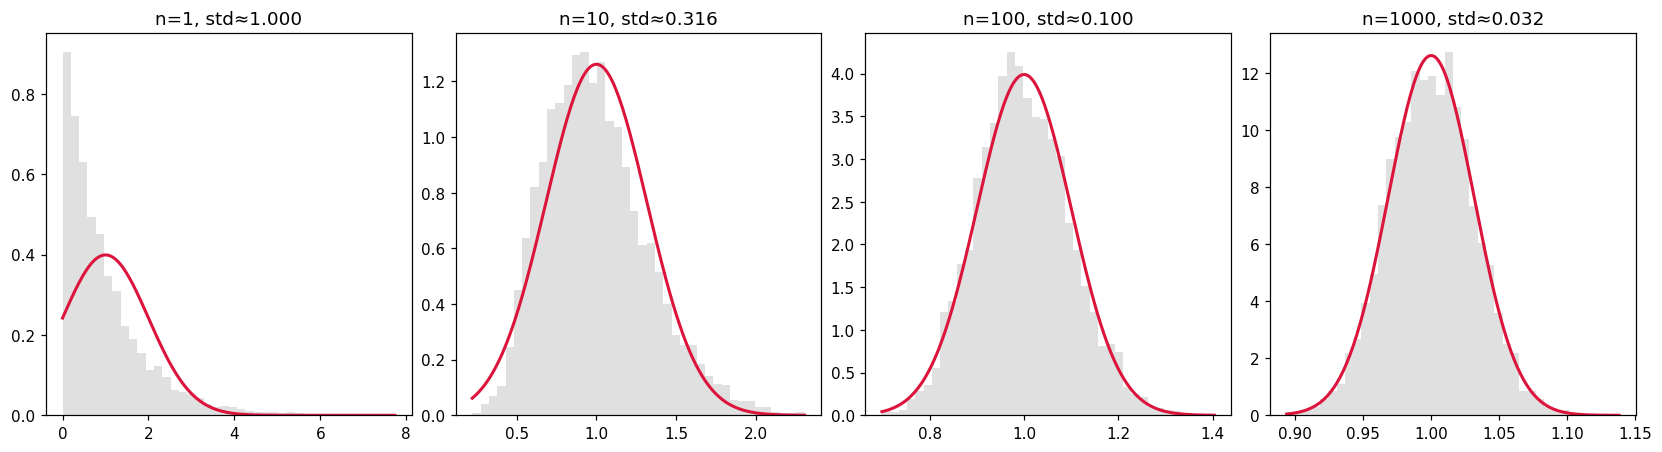

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)
n_runs = 5000
fig, axes = plt.subplots(1, 4, figsize=(15, 4), dpi=110, constrained_layout=True)
for ax, n_samp in zip(axes, [1, 10, 100, 1000]):
    means = []
    for _ in range(n_runs):
        X = rng.exponential(scale=1.0, size=n_samp)
        means.append(X.mean())
    means = np.array(means)
    ax.hist(means, bins=40, density=True, color="lightgray", alpha=0.7)
    # 期望 Exp(1)=1, var Exp(1)=1; 理论 std = 1/sqrt(n_samp)
    sd_theory = 1/np.sqrt(n_samp) if n_samp > 1 else 1.0
    xs = np.linspace(means.min(), means.max(), 200)
    from scipy.stats import norm
    ax.plot(xs, norm.pdf(xs, loc=1, scale=max(sd_theory, 1e-3)), color="crimson", lw=2)
    ax.set_title(f"n={n_samp}, std≈{sd_theory:.3f}")
plt.show()


## 3. LLN & CLT 公式

### LLN
若 X_i iid, $E[X_i] = \mu$, $\mathrm{Var}(X_i) < \infty$:
- WLLN (Khinchine): $\bar X_n \xrightarrow{P} \mu$
- SLLN (Kolmogorov): $\bar X_n \xrightarrow{a.s.} \mu$ (在不加更强假设时, 一次抽样几乎必然)

### CLT
若 $X_i$ iid, $E[X_i]=\mu$, $\mathrm{Var}(X_i)=\sigma²$:
$$\sqrt n (\bar X_n - \mu) \xrightarrow{d} \mathcal N(0, \sigma²)$$

### Berry-Esseen
$|F_n(x) - Φ(x)| \le C E|X-\mu|³/(σ³ \sqrt n)$

### 矩母函数 (MGF)
$M_X(t) = E[e^{tX}]$; 唯一决定分布 (有限区间内); 之和 X+Y 满足 $M_{X+Y}(t) = M_X(t) M_Y(t)$. 一阶矩 $E[X^k] = M^{(k)}(0)$.

### 重要 MGF
- Normal(μ,σ²): $e^{μt + σ²t²/2}$
- Poisson(λ): $e^{λ(e^t - 1)}$
- Exp(λ): $λ/(λ - t)$, 定义域 $t < λ$


## 4. 符号推导: 用 MGF 推 CLT (sketch)


In [2]:
import sympy as sp
from sympy import exp, oo, series, symbols

t = symbols("t", real=True)
mu, sigma2 = symbols("mu sigma2", positive=True)
# Let Y_i = X_i - mu. E[Y]=0, Var=σ²; take Z_n = sqrt(n) X̄_n / σ
# MGF of standardized Y_i / σ = 1: M_Y(t) ≈ 1 + σ² t²/(2 σ² 1²) + o(t²) = 1 + t²/2 + o(t²)
# M_{Z_n}(t) ≈ (1 + t²/(2n) + o(t²))^n -> e^{t²/2}
# 这是 N(0,1) 的 MGF! 故 CLT 成立 (需要更严格 Taylor 第三阶 + 取极限)
print("Chebyshev argument: M_{Z_n}(t) -> N(0,1) MGF= e^{t²/2}")

# 验证标准化 Bernoulli 的 CLT → Bin(n,p) 归一化 -> Normal(0,1)
# M_X = 1 - p + p e^t; log M = log((1-p)+p e^t) ≈ p*(e^t-1) at small t ≈ p t + p t²/2
# mean μ = p, var = p(1-p)
# Z_n = sqrt(n) X̄_n -> N(0, p(1-p)); 即 Bin(n, p) ~ N(np, np(1-p))
print("Bin(n,p) MGF -> e^{n p (e^t -1)} → N(np, np(1-p))")


Chebyshev argument: M_{Z_n}(t) -> N(0,1) MGF= e^{t²/2}
Bin(n,p) MGF -> e^{n p (e^t -1)} → N(np, np(1-p))


## 5. 数值验证: Berry-Esseen 的工程无关 σ


In [3]:
import numpy as np
from scipy.stats import norm
rng = np.random.default_rng(seed=20240717)

# X_i ~ Bern(p); 取样本均值 + 由 CLT 跟 N(μ, σ²/n) 对比
p = 0.3; n = 50
N = 50_000
sample_means = rng.binomial(n=1, p=p, size=(N, n)).mean(axis=1)
# CLT 预测: N(p, p(1-p)/n) = N(0.3, 0.0042)
μ_clt = p; σ_clt = np.sqrt(p*(1-p)/n)
emp_mean = sample_means.mean(); emp_std = sample_means.std()
print(f"CLT predict: μ={μ_clt:.4f} σ={σ_clt:.4f}")
print(f"empirical  : μ={emp_mean:.4f} σ={emp_std:.4f}")
# KS-distance vs Normal as proxy Berry-Esseen
xs = np.sort(sample_means)
cdf_emp = np.arange(1, len(xs)+1) / len(xs)
cdf_normal = norm.cdf((xs - μ_clt) / σ_clt)
ks = np.max(np.abs(cdf_emp - cdf_normal))
print(f"KS vs CLT-predicted Normal: {ks:.4f}")
print(f"Berry-Esseen upper bound 1/sqrt(n): {1/np.sqrt(n):.4f}")


CLT predict: μ=0.3000 σ=0.0648
empirical  : μ=0.2999 σ=0.0648
KS vs CLT-predicted Normal: 0.0730
Berry-Esseen upper bound 1/sqrt(n): 0.1414


## 6. 可视化: 指数和的均值分布收敛


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35770 (\N{CJK UNIFIED IDEOGRAPH-8BBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


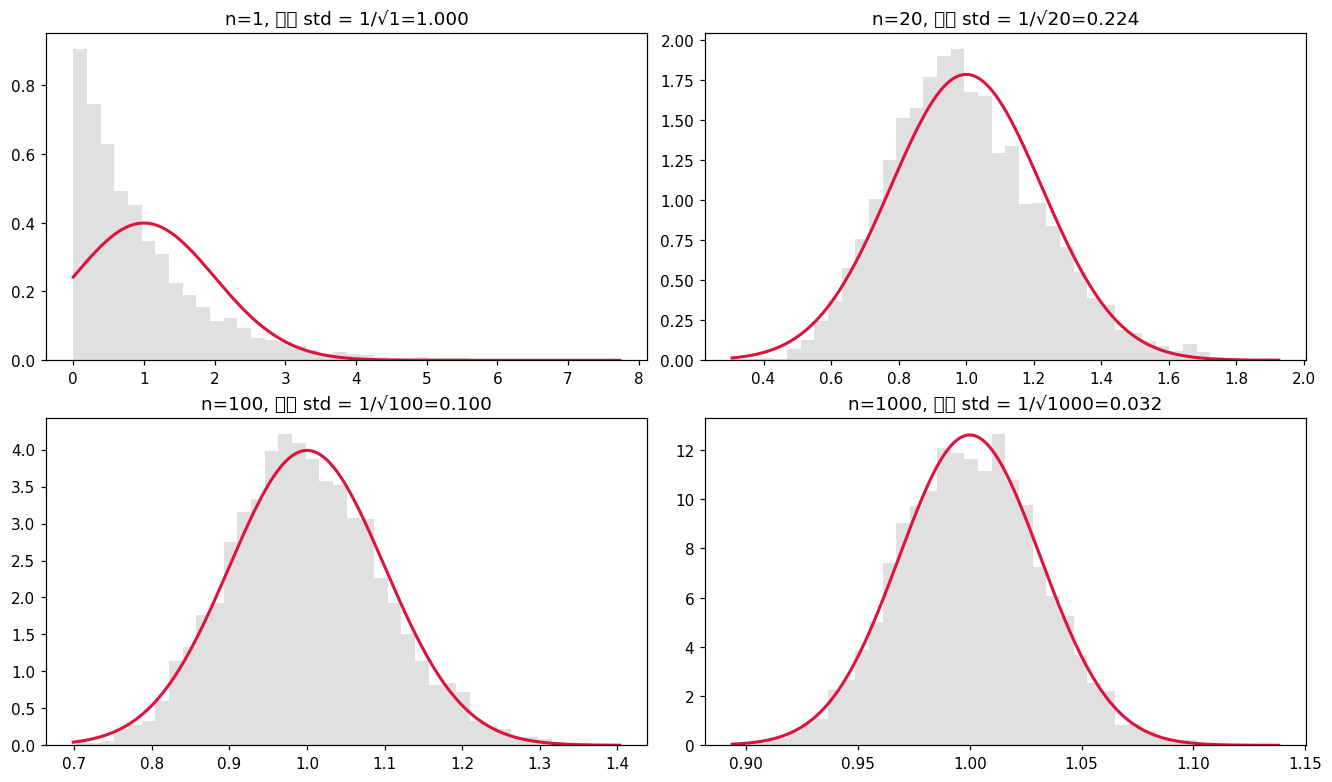

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
rng = np.random.default_rng(seed=20240717)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=110, constrained_layout=True)
for ax, n in zip(axes.ravel(), [1, 20, 100, 1000]):
    means = rng.exponential(1.0, size=(5000, n)).mean(axis=1)
    ax.hist(means, bins=40, density=True, color="lightgray", alpha=0.7)
    xs = np.linspace(means.min(), means.max(), 200)
    ax.plot(xs, norm.pdf(xs, loc=1, scale=1/np.sqrt(n)), color="crimson", lw=2)
    ax.set_title(f"n={n}, 理论 std = 1/√{n}={1/np.sqrt(n):.3f}")
plt.show()


## 7. 工程案例: Hoeffding 不等式 + 样本量决策


In [5]:
# Hoeffding: P(|X̄ - μ| ≥ ε) ≤ 2 exp(-2 n ε² / (b-a)²)
# 用它决定"需要多少样才让均值估计 ±0.05 with 95% prob"
import numpy as np
target_eps = 0.05
confidence = 0.95  # 两边/1 各 0.975
alpha = 1 - confidence
# X ~ Uniform(0, 1) ⇒ (b-a)² = 1
b_minus_a = 1
n_needed = int(np.ceil(np.log(2 / alpha) / (2 * target_eps ** 2 / b_minus_a**2)))
print(f"Hoeffding gives n ≥ {n_needed} to bound |X̄-μ|<0.05 with 95% confidence for U(0,1)")
# 验证: 用蒙div洛
rng = np.random.default_rng(seed=20240717)
N_exp = 10000
violations = []
for trial in range(N_exp):
    X = rng.uniform(0, 1, size=n_needed)
    if abs(X.mean() - 0.5) >= target_eps:
        violations.append(True)
print(f"empirical violation {(sum(violations)/N_exp):.4f} (expect ≤ {alpha:.4f})")


Hoeffding gives n ≥ 738 to bound |X̄-μ|<0.05 with 95% confidence for U(0,1)
empirical violation 0.0000 (expect ≤ 0.0500)


## 8. pitfalls
- 把 LLN 当作 CLT 误用 — LLN 谈样本均值"收敛到真值", CLT 谈"收敛速度+分布"
- 写 "n ≈ 30" 就够 → 实际依赖分布偏度; 重尾分布对 sample size 更大
- Berry-Esseen 的第三阶绝对矩 infinite (如 Cauchy) → CLT 不成立
- 强大数律几乎处处 vs 弱大数律收敛在概率 — 工程护栏几乎从来由 SLLN
- 梯度噪声在 SGD 不严格 iid: batch 随机梯度方差由 batch 内估计, 不能直接除 n

## 9. 课后 -> exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Stat 110 | §10.1-10.5 |
| Bertsekas | §5.5-5.6 |
| Murphy | §2.7 (limit laws) |

下一章 ch07 次序统计量 + Bootstrap — 把分布推断还没决定时怎么给出置信区间。
